In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples
from pathlib import Path
from scipy.optimize import curve_fit

In [9]:
chain_dir = Path(r'/home/theppawan/cosmo-research/quintom-project/chains')
sample = loadMCSamples(str(chain_dir / 'quintom/DESI+CMB+SNIa/quintom_DESI+CMB+SNIa'), settings={'ignore_rows': 0.3})
best_fit_sample = sample.getParamBestFitDict(best_sample=False)

In [10]:
best_fit_sample

{'H0': 65.72596,
 'omega_b': 0.022390748,
 'omega_cdm': 0.11200883,
 'lambda_qtm': 0.66654901,
 'delta_qtm': -0.06008396,
 'Mb': -19.485557,
 'theta_s_100': 1.042127758,
 'sigma8': 0.725855029,
 'Omega_m': 0.3126083384,
 'w_qtm': -0.9345770079,
 'Omega_qtm': 0.6873079054,
 'age': 14.11235286,
 'rs_rec': 149.060959,
 'da_rec': 13.13753369,
 'chi2__BAO': 13.35411578,
 'chi2__SN': 1402.538769,
 'chi2__bao.desi_2024_bao_all': 13.35411578,
 'chi2__cmb_distance_prior.CMB_Distance_Prior_wcdm': 0.002261118354,
 'chi2__sn.pantheonplus': 1402.538769,
 'weight': 1,
 'loglike': 709.6339717395058,
 'minuslogprior': 1.6863990000000013,
 'minuslogprior__0': 1.6863990000000013}

In [73]:
fixed_params = {
    'h': best_fit_sample['H0']/100,
    'Neff': 3.044,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
    'omega_b': best_fit_sample['omega_b'],
    'omega_cdm': best_fit_sample['omega_cdm'],
}
quintom_params = {    
    'Omega_Lambda': 0,
    'Omega_fld' : 0,
    'Omega_qtm': -1,
    'coupled_baryon_qtm' : 'yes',
    'coupled_cdm_qtm' : 'yes',
}

In [74]:
qtm = Class()
qtm.set(fixed_params)
qtm.set(quintom_params)
qtm.set({'lambda_qtm' : best_fit_sample['lambda_qtm'], 
         'delta_qtm': best_fit_sample['delta_qtm'],
         })
qtm.compute()

bg_qtm = qtm.get_background()
derived = qtm.get_current_derived_parameters(['100*theta_s'])
qtm.struct_cleanup()
qtm.empty()

In [75]:
z = bg_qtm['z']
a = 1/(z+1.0)
w_qtm = bg_qtm['(.)p_qtm']/bg_qtm['(.)rho_qtm']

In [93]:
w_qtm = bg_qtm['(.)p_qtm']/bg_qtm['(.)rho_qtm']
# Create a boolean mask for z < 10
low_z_mask = z < 4
z_low = z[low_z_mask]
w_qtm_low = w_qtm[low_z_mask]

In [94]:

# 1. Define the CPL model function
# The independent variable (z) must be the first argument
def cpl_model(z, w0, wa):
    return w0 + wa * (z / (1 + z))

# 3. Run the curve fit
# popt contains the optimal values for [w0, wa]
# pcov contains the covariance matrix
popt, pcov = curve_fit(cpl_model, z_low, w_qtm_low)

w0_fit, wa_fit = popt

# 4. Extract the 1-sigma errors (square root of the diagonal of the covariance matrix)
errors = np.sqrt(np.diag(pcov))
w0_err, wa_err = errors

print(f"Best fit w0: {w0_fit:.5f} ± {w0_err:.5f}")
print(f"Best fit wa: {wa_fit:.5f} ± {wa_err:.5f}")

w_cpl_fit = cpl_model(z_low, w0_fit, wa_fit)

Best fit w0: -0.88097 ± 0.00227
Best fit wa: -0.29955 ± 0.00411


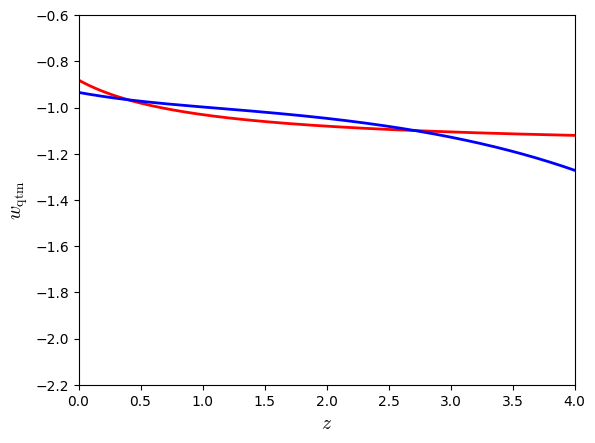

In [102]:
plt.plot(z_low, w_cpl_fit, color='red', linewidth=2)
plt.plot(z_low, w_qtm_low, color='blue', linewidth=2)
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$w_{\rm qtm}$', fontsize=14)
plt.xlim(0, 4)
plt.ylim(-2.2, -0.6)
plt.show()